<a href="https://colab.research.google.com/github/Shikaaaaaaaaa/Ahmedfathy.com/blob/main/California_Housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# California Housing Project

This notebook follows a complete machine learning workflow for predicting `median_house_value` using the California Housing dataset.

**Workflow**
1. Load and inspect the data
2. Perform exploratory data analysis
3. Create a stratified train/test split
4. Build preprocessing pipelines
5. Train and compare models
6. Tune the best model
7. Evaluate the final model on the test set


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
housing = pd.read_csv('/content/housing.csv')

## Initial Exploration

At this stage, the goal is to understand:
- the shape and data types of the dataset
- missing values
- duplicate rows
- the categorical feature `ocean_proximity`


In [3]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [6]:
housing.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [7]:
housing.duplicated().sum()


np.int64(0)

In [8]:
housing['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


## Visualization

These plots help us understand feature distributions, geographic patterns, and the relationship between `median_income` and `median_house_value`.


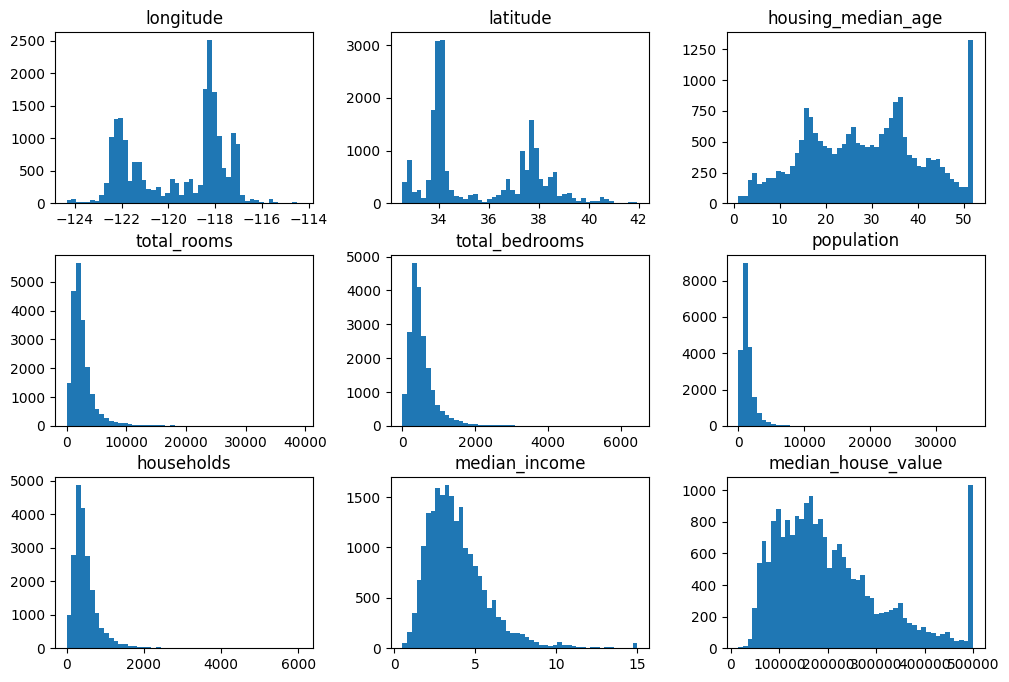

In [9]:
housing.hist(figsize=(12,8),grid = False , bins=50)
plt.show()

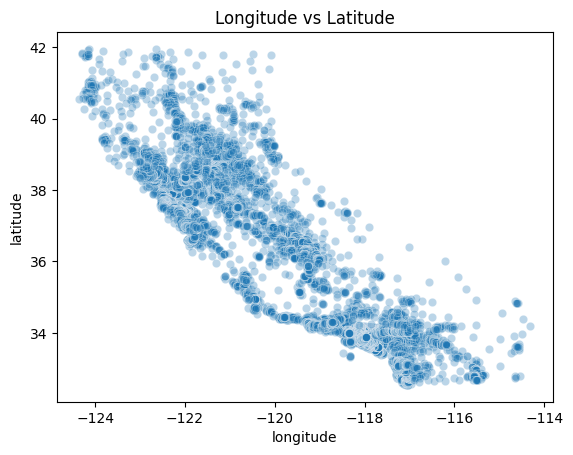

In [10]:
sns.scatterplot(x='longitude', y='latitude', data=housing, alpha=0.3)
plt.title('Longitude vs Latitude')
plt.show()

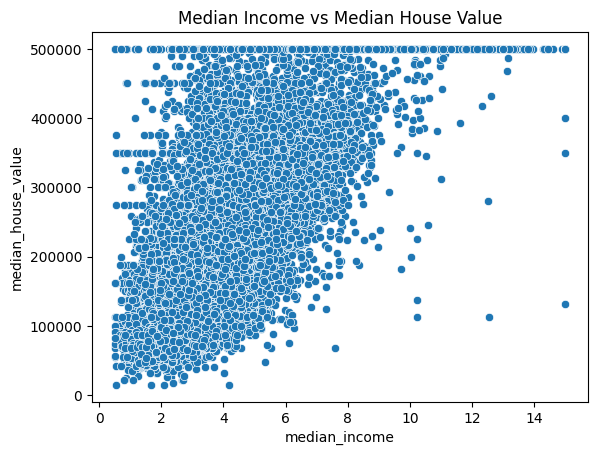

In [11]:
sns.scatterplot(x='median_income', y='median_house_value', data=housing)
plt.title('Median Income vs Median House Value')
plt.show()

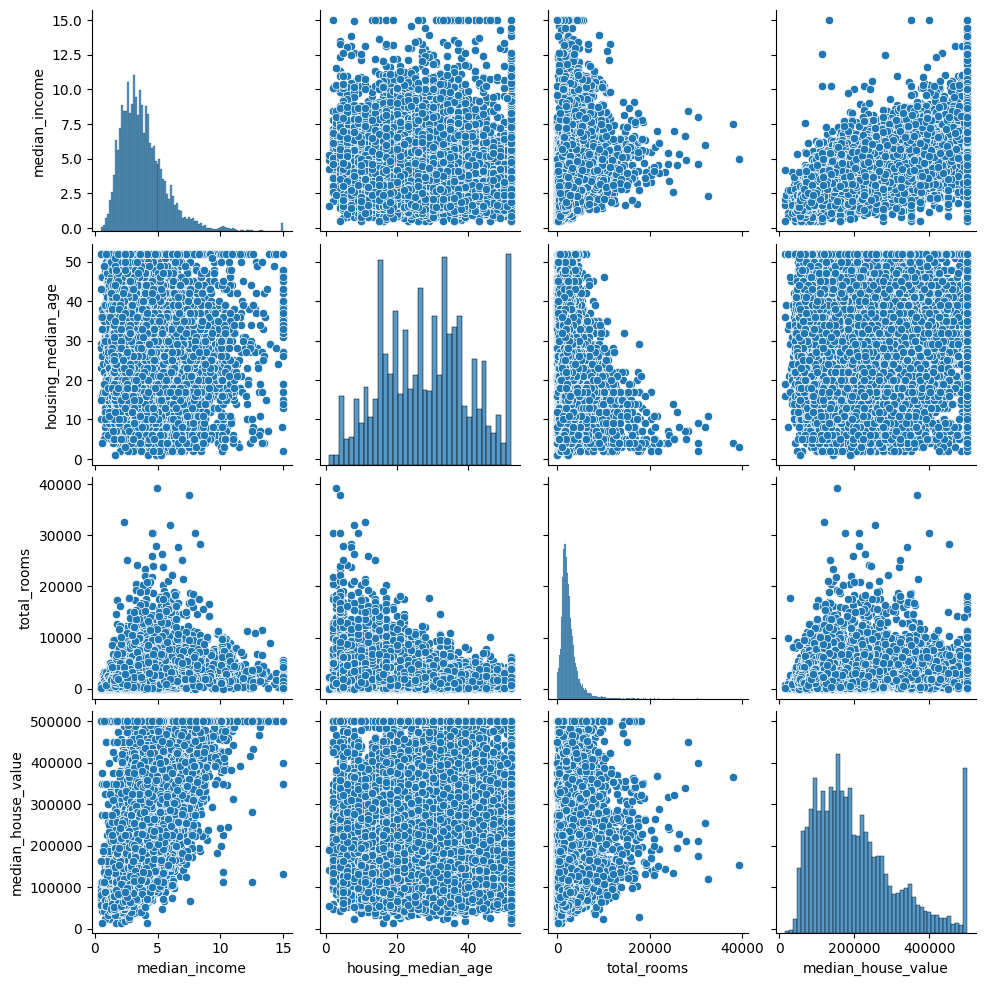

In [12]:
sns.pairplot(housing[['median_income', 'housing_median_age', 'total_rooms', 'median_house_value']])
plt.show()

## Correlation

`median_income` is expected to be one of the strongest numerical predictors of `median_house_value`.


In [13]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix = corr_matrix['median_house_value'].sort_values(ascending=False)
corr_matrix

,median_house_value
median_house_value,1.000000
median_income,0.688075
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
population,-0.024650
longitude,-0.045967
latitude,-0.144160


## Train/Test Split

I use stratified sampling based on `median_income` categories so the train and test sets keep a similar income distribution.


In [14]:
from sklearn.model_selection import StratifiedShuffleSplit
housing['income_cat'] = pd.cut(housing['median_income'],
                               bins = [0,1.5,3,4.5,6,np.inf]
                               ,labels = [1,2,3,4,5]
                               )

In [15]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

In [16]:
for train_index, test_index in split.split(housing, housing['income_cat']):
    train_set = housing.iloc[train_index].copy()
    test_set = housing.iloc[test_index].copy()

for df_ in (train_set, test_set):
    df_.drop('income_cat', axis=1, inplace=True)

In [17]:
housing = train_set.drop('median_house_value',axis = 1)
housing_labels = train_set["median_house_value"].copy()

## Preprocessing

The preprocessing step handles:
- missing numerical values
- scaling numerical features
- imputing and encoding the categorical feature

I use separate pipelines for numerical and categorical columns, then combine them with a `ColumnTransformer`.


In [18]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [19]:
housing_num = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
housing_cat = ['ocean_proximity']

In [20]:
num_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

cat_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder()
)

In [21]:
full_pipeline = ColumnTransformer([
    ('num', num_pipeline, housing_num),
    ('cat', cat_pipeline, housing_cat)
])

full_pipeline

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['longitude', 'latitude', 'housing_median_age',
                                  'total_rooms', 'total_bedrooms', 'population',
                                  'households', 'median_income']),
                                ('cat',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder())]),
                                 ['ocean_proximity'])])

In [22]:
housing_prepared = full_pipeline.fit_transform(housing)
housing_prepared.shape

(16512, 13)

## Modelling

I train three regression models:
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor


In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score


In [24]:
lin_reg = make_pipeline(full_pipeline, LinearRegression())
lin_reg.fit(housing, housing_labels)

lin_pred = lin_reg.predict(housing)

lin_mse = mean_squared_error(housing_labels, lin_pred)
lin_mae = mean_absolute_error(housing_labels, lin_pred)
lin_rmse = np.sqrt(lin_mse)
lin_r2 = r2_score(housing_labels, lin_pred)

print('Linear Regression')
print('MSE:', lin_mse)
print('MAE:', lin_mae)
print('RMSE:', lin_rmse)
print('R2:', lin_r2)

Linear Regression
MSE: 4767980139.451871
MAE: 49905.329442715316
RMSE: 69050.56219504567
R2: 0.6438078994746375


In [25]:
tree_reg = make_pipeline(full_pipeline, DecisionTreeRegressor(random_state=42))
tree_reg.fit(housing, housing_labels)

tree_pred = tree_reg.predict(housing)

tree_mse = mean_squared_error(housing_labels, tree_pred)
tree_mae = mean_absolute_error(housing_labels, tree_pred)
tree_rmse = np.sqrt(tree_mse)
tree_r2 = r2_score(housing_labels, tree_pred)

print('Decision Tree')
print('MSE:', tree_mse)
print('MAE:', tree_mae)
print('RMSE:', tree_rmse)
print('R2:', tree_r2)

Decision Tree
MSE: 0.0
MAE: 0.0
RMSE: 0.0
R2: 1.0


In [26]:
forest_reg = make_pipeline(full_pipeline, RandomForestRegressor(n_estimators=100, random_state=42))
forest_reg.fit(housing, housing_labels)

forest_pred = forest_reg.predict(housing)

forest_mse = mean_squared_error(housing_labels, forest_pred)
forest_mae = mean_absolute_error(housing_labels, forest_pred)
forest_rmse = np.sqrt(forest_mse)
forest_r2 = r2_score(housing_labels, forest_pred)

print('Random Forest')
print('MSE:', forest_mse)
print('MAE:', forest_mae)
print('RMSE:', forest_rmse)
print('R2:', forest_r2)

Random Forest
MSE: 336442403.7696726
MAE: 11813.920286458333
RMSE: 18342.366362322846
R2: 0.9748660600506824


Training metrics can look overly optimistic, especially for tree-based models.  
So the main model comparison should be based on **cross-validation**.


In [27]:
models = {
    'LinearRegression': LinearRegression(),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=100, random_state=42),
    'DecisionTreeRegressor': DecisionTreeRegressor(random_state=42)
}

cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        housing_prepared,
        housing_labels,
        scoring='neg_mean_squared_error',
        cv=10
    )
    rmse_scores = np.sqrt(-scores)
    cv_results.append({
        'Model': name,
        'Mean RMSE': rmse_scores.mean(),
        'Std RMSE': rmse_scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values('Mean RMSE')
cv_results_df

,Model,Mean RMSE,Std RMSE
1,RandomForestRegressor,49432.126788,2124.858792
2,DecisionTreeRegressor,69081.361563,2296.288087
0,LinearRegression,69204.322755,2372.070791


Based on cross-validation, **Random Forest** performed best, so it was selected for hyperparameter tuning.


## Fine Tuning

I use `GridSearchCV` to search for stronger Random Forest hyperparameters.


In [28]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    rf,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)

grid_search.fit(housing_prepared, housing_labels)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='neg_mean_squared_error')

In [29]:
print('Best Parameters:', grid_search.best_params_)
best_rmse = np.sqrt(-grid_search.best_score_)
print('Best CV RMSE:', best_rmse)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV RMSE: 49729.12139602256


## Final Evaluation on the Test Set

After selecting the tuned Random Forest model, I evaluate it once on the untouched test set.


In [30]:
final_model = grid_search.best_estimator_

X_test = test_set.drop('median_house_value', axis=1)
y_test = test_set['median_house_value'].copy()

X_test_prepared = full_pipeline.transform(X_test)
final_pred = final_model.predict(X_test_prepared)

In [31]:
mse = mean_squared_error(y_test, final_pred)
mae = mean_absolute_error(y_test, final_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, final_pred)

print('MSE:', mse)
print('MAE:', mae)
print('RMSE:', rmse)
print('R2:', r2)

MSE: 2215874005.607791
MAE: 30864.019818313955
RMSE: 47073.07091754043
R2: 0.8299817020210175


## Conclusion

- Random Forest achieved the best cross-validation performance among the tested models.
- After tuning with `GridSearchCV`, the final model was evaluated on the test set.
- The final test metrics show that the model provides strong predictive performance for this dataset.
